## Import Required Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Dataset

In [29]:
df = pd.read_csv("data/superstore_sales.csv", encoding="latin-1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Inspect Dataset Structure

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Visualization

In [34]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [32]:
df.columns = df.columns.str.strip()

## Convert Date Columns

In [36]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

Save Charts In Images Folder

In [6]:
plt.savefig("images/region_sales.png")

<Figure size 640x480 with 0 Axes>

Sales Trend Over Time (Time-Series Analysis)

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

## Check Missing Values
The dataset was checked for missing values using `isnull().sum()`.

Result:
- No missing values were found in any column.
- The dataset is clean and ready for exploratory data analysis.

In [38]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Monthly Sales Trend

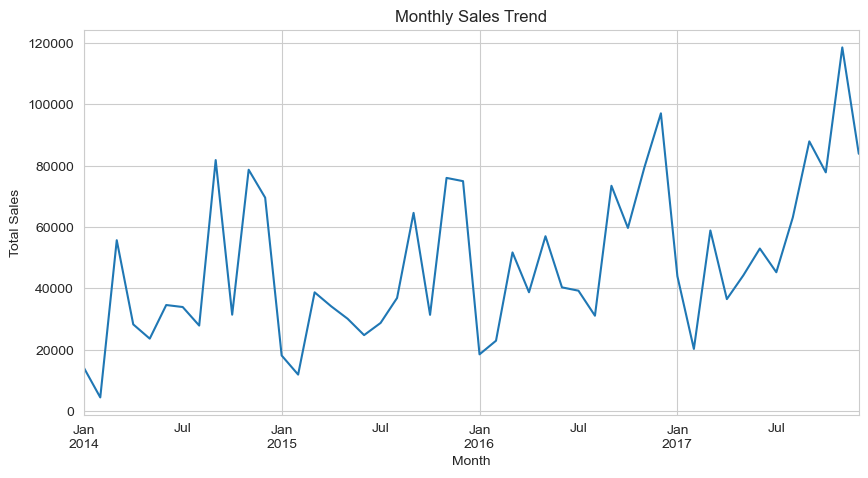

In [39]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.savefig("images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

## Sales by Region

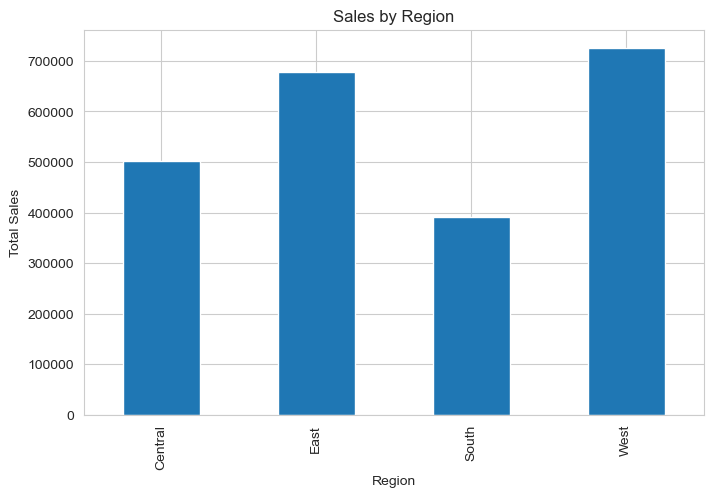

In [40]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.savefig("images/sales_by_region.png", dpi=300, bbox_inches="tight")

plt.show()

## Top 10 Cities by Sales

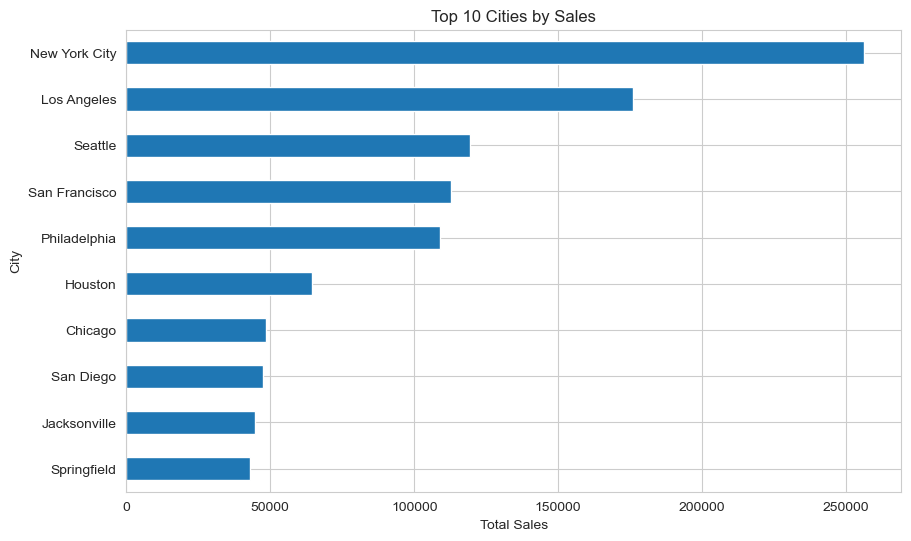

In [42]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_cities.plot(kind="barh")

plt.title("Top 10 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.gca().invert_yaxis()

plt.savefig("images/top_10_cities_sales.png", dpi=300, bbox_inches="tight")

plt.show()

## Sales by Category

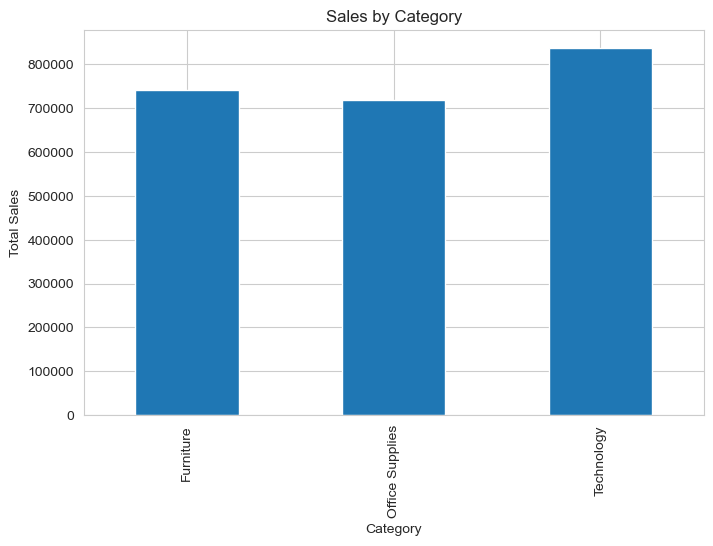

In [43]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("images/sales_by_category.png", dpi=300, bbox_inches="tight")

plt.show()

## Discount vs Profit Analysis

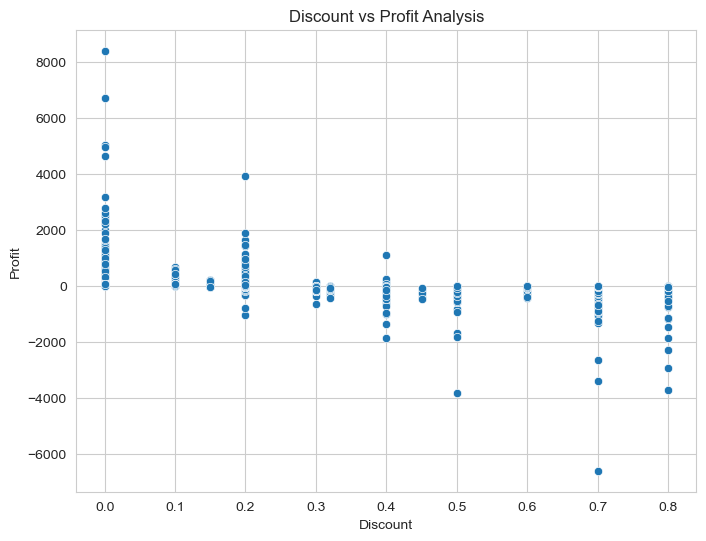

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=df["Discount"], y=df["Profit"])

plt.title("Discount vs Profit Analysis")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.savefig("images/discount_vs_profit.png", dpi=300, bbox_inches="tight")

plt.show()

## Correlation Heatmap

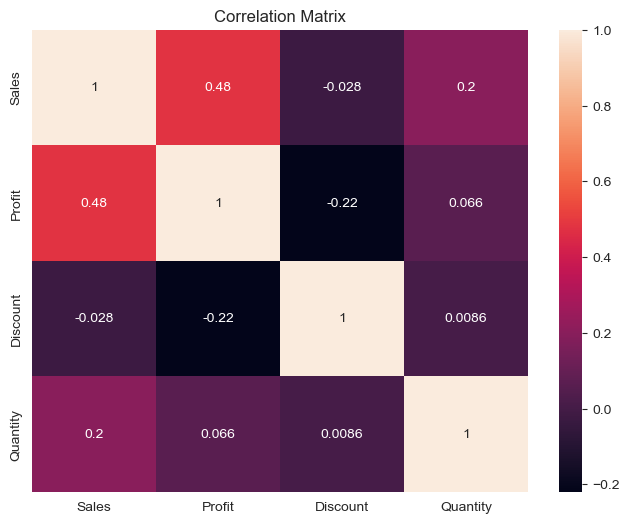

In [46]:
plt.figure(figsize=(8,6))

corr = df[["Sales","Profit","Discount","Quantity"]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

## Key Business Insights

1. Technology category generates the highest revenue.
2. A few cities contribute significantly to overall sales.
3. High discounts can reduce profitability.
4. Sales trends vary across months, indicating seasonal demand.

## Ship Mode Distribution

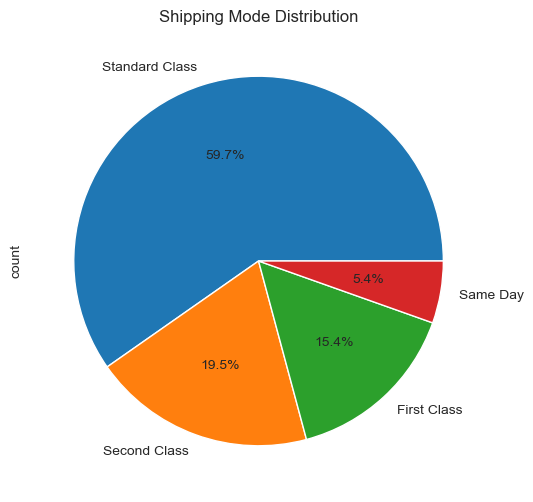

In [47]:
ship_mode = df["Ship Mode"].value_counts()

plt.figure(figsize=(6,6))
ship_mode.plot(kind="pie", autopct="%1.1f%%")

plt.title("Shipping Mode Distribution")

plt.savefig("images/shipping_mode_distribution.png", dpi=300, bbox_inches="tight")
plt.show()